In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import sys
sys.path.append('../src/')

import FSC as controller

import os
import time as measure_time

import pickle
import matplotlib.pyplot as plt

In [3]:
def generate_single_sequence(N: int = 3) -> list[tuple[str, str]]:
    """
    Generates a single action-observation sequence for an agent in the T-maze.

    The agent's policy at the end of the maze is stochastic (80/20 bias).

    Args:
        N: The length of the corridor.

    Returns:
        A list of (action, observation) tuples representing one full episode.
    """
    position = 0
    # FSC memory states (1:Initial, 2:Corr_u, 3:Corr_d, 4:End_u, 5:End_d)
    fsc_state = 1
    initial_cue = None
    
    sequence = []
    is_done = False

    while not is_done:
        # 1. Determine the policy based on the current FSC memory state
        actions = ['U', 'D', 'R']
        if fsc_state == 2:  # Agent is in the corridor after u obs
            probabilities = [0.3, 0.1, 0.6]
        elif fsc_state == 3:  # Agent is in the corridor after d obs
            probabilities = [0.1, 0.3, 0.6]
        elif fsc_state == 1:  # Initial state
            probabilities = [0.0, 0.0, 1.0]
        elif fsc_state == 4:  # Agent is at the end and remembers 'u'
            probabilities = [1, 0., 0.0]
        else:  # fsc_state == 5, agent is at the end and remembers 'd'
            probabilities = [0., 1, 0.0]

        # 2. Sample an action based on the policy
        action = np.random.choice(actions, p=probabilities)
        observation = ''

        # 3. Determine the observation and update states
        if fsc_state == 1:
            initial_cue = np.random.choice(['u', 'd'], p = [0.5, 0.5])
            observation = initial_cue
            fsc_state = 2 if observation == 'u' else 3
            if action == 'R':
                position += 1
                if position == N - 1:
                    observation = 'e'
                    fsc_state = 4 if initial_cue == 'u' else 5

        elif fsc_state in [2, 3]:
            if action == 'R':
                position += 1
            if position == N - 1:
                observation = 'e'
                fsc_state = 4 if fsc_state == 2 else 5
            else:
                observation = np.random.choice(['u', 'd'])
        
        elif fsc_state in [4, 5]:
            if (initial_cue == 'u' and action == 'U') or \
               (initial_cue == 'd' and action == 'D'):
                observation = 'w'  # 'w' for win
            else:
                observation = 'l'  # 'l' for lose
            is_done = True

        # 4. Record the step
        sequence.append((action, observation))
        
    return sequence

# Corridor length = 7

In [5]:
CORRIDOR_LENGTH = 7
NUM_SEQUENCES = 1000
OUTPUT_FILENAME = f'../data/TMaze/output_sequences_length_{CORRIDOR_LENGTH}.txt'

print(f"Generating {NUM_SEQUENCES} sequences for a T-maze of length N={CORRIDOR_LENGTH}...")

with open(OUTPUT_FILENAME, 'w') as f:
    for i in range(NUM_SEQUENCES):
        # Generate one sequence
        seq = generate_single_sequence(N=CORRIDOR_LENGTH)
        
        # Format the sequence into a single string: "a0y0 a1y1 a2y2..."
        formatted_seq = " ".join([f"{action}{obs}" for action, obs in seq])
        
        # Write the formatted string to the file, followed by a newline
        f.write(formatted_seq + "\n")

Generating 1000 sequences for a T-maze of length N=7...


In [6]:
with open(OUTPUT_FILENAME, 'r') as f:
    lines = f.readlines()

action_sequences = []
observation_sequences = []

for line in lines:
    # Split each line into individual action-observation pairs
    pairs = line.strip().split()
    
    actions = []
    observations = []
    
    for pair in pairs:
        action = pair[0] 
        observation = pair[1:]
        
        actions.append(action)
        observations.append(observation)
    observations[-1] = "na"
    action_sequences.append(actions)
    observation_sequences.append(observations)

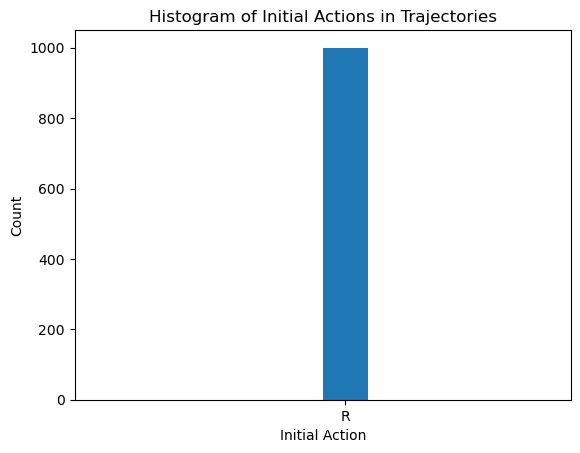

In [7]:
trajectories_data = []
num_seq = NUM_SEQUENCES
np.random.seed(73)

for idx_trj in np.random.choice(len(action_sequences), num_seq, replace=False):
    traj_dict = {
        'actions': np.array(action_sequences[idx_trj]),
        'observations': np.array(observation_sequences[idx_trj])
    }
    trajectories_data.append(traj_dict)

initial_actions = [trj['actions'][0] for trj in trajectories_data]

plt.hist(initial_actions, align = 'left', rwidth = 1)
plt.xlabel("Initial Action")
plt.ylabel("Count")
plt.title("Histogram of Initial Actions in Trajectories")
plt.show()

In [8]:
ActSpace = np.array(list(set(action for seq in action_sequences for action in seq)))[::-1]
ObsSpace = np.array(list(set(obs for seq in observation_sequences for obs in seq)))
ActSpace = np.array(["R", "D", "U"])
ObsSpace = np.array(["d", "u", "e", "na"])
print(f"Action Space: {ActSpace}")
print(f"Observation Space: {ObsSpace}")

idx_D = np.where(ActSpace == "D")[0][0]
idx_R = np.where(ActSpace == "R")[0][0]
idx_U = np.where(ActSpace == "U")[0][0]

idx_obs_d = np.where(ObsSpace == "d")[0][0]
idx_obs_u = np.where(ObsSpace == "u")[0][0]
idx_obs_e = np.where(ObsSpace == "e")[0][0]
idx_obs_na = np.where(ObsSpace == "na")[0][0]

Action Space: ['R' 'D' 'U']
Observation Space: ['d' 'u' 'e' 'na']


In [9]:
A = len(ActSpace)
Y = len(ObsSpace)

In [10]:
AllowedObsFromAct = np.zeros((A, Y), dtype = bool)
for trj in trajectories_data:
    actions = trj["actions"]
    observations = trj["observations"]
    for i in range(len(actions)):
        act = np.where(ActSpace == actions[i])[0][0]
        obs = observations[i]
        obs_idx = np.where(ObsSpace == obs)[0][0]
        AllowedObsFromAct[act, obs_idx] = True

/var/folders/tq/vdh27z_571gbg17w072s1p7h0000gn/T/ipykernel_24081/3312522797.py:24: RuntimeWarning: divide by zero encountered in log
  zeta_real = np.log(policy_real)


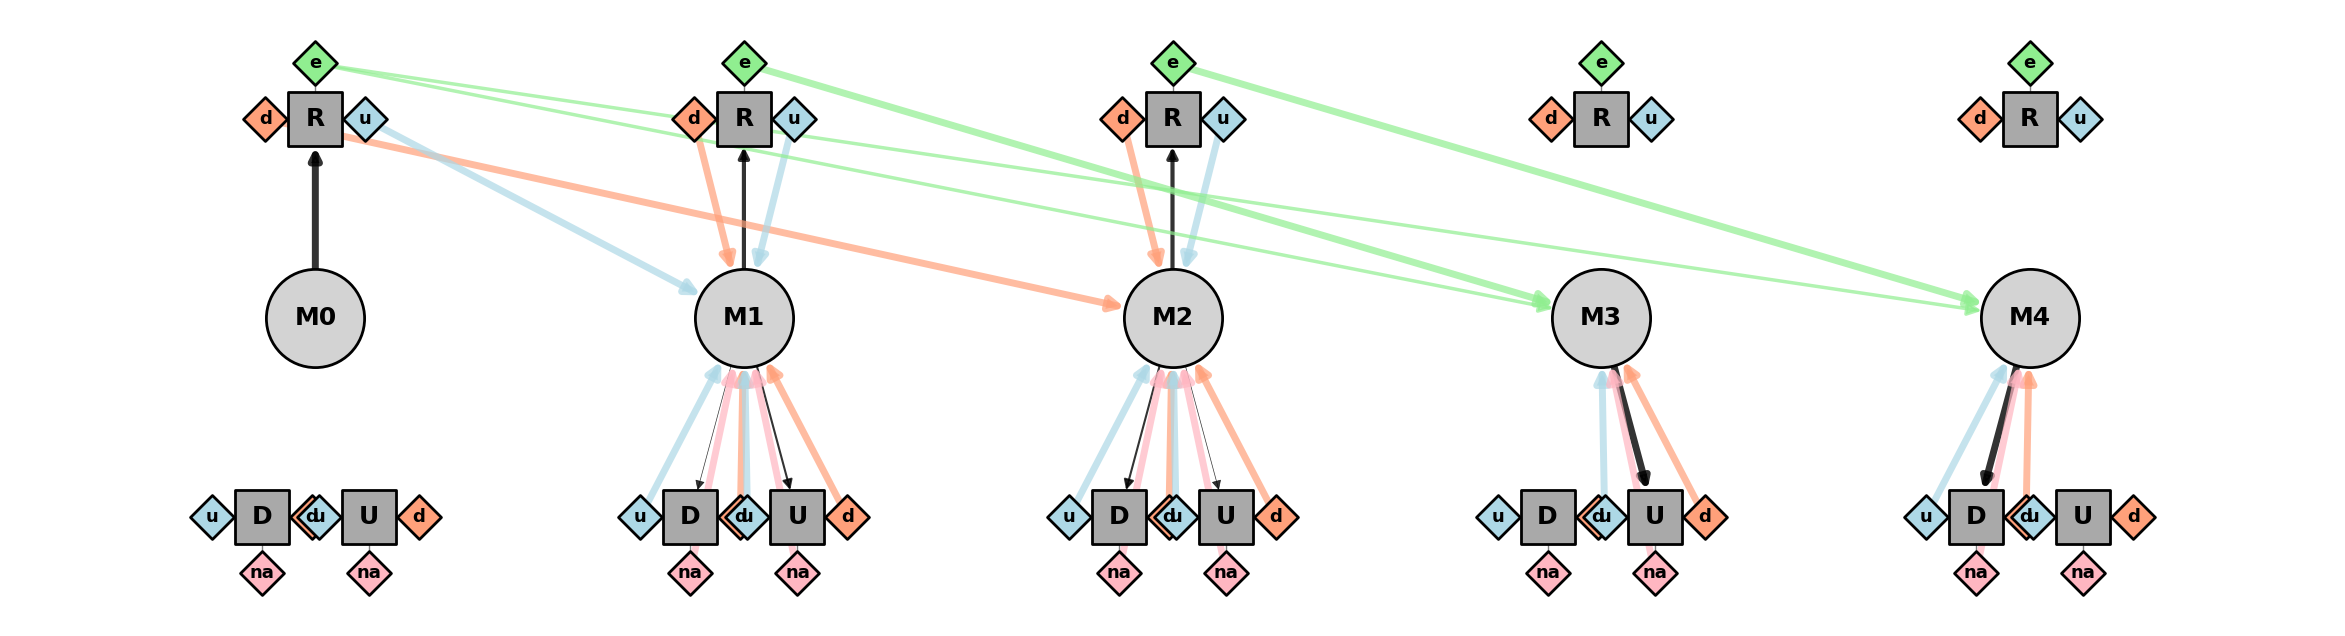

In [11]:
M = 5
psi_real = np.ones(M)
psi_real[1:] = -np.inf

policy_real = np.zeros((A, M))
policy_real[idx_R, 0] = 1
policy_real[idx_U, 0] = 0.
policy_real[idx_D, 0] = 0.

policy_real[idx_R, 1] = 0.6
policy_real[idx_U, 1] = 0.3
policy_real[idx_D, 1] = 0.1

policy_real[idx_R, 2] = 0.6
policy_real[idx_U, 2] = 0.1
policy_real[idx_D, 2] = 0.3

policy_real[idx_U, 3] = 1
policy_real[idx_D, 3] = 0.

policy_real[idx_U, 4] = 0.
policy_real[idx_D, 4] = 1

zeta_real = np.log(policy_real)

theta_real = np.ones((Y, A, M, M))
theta_real *= - np.inf
theta_real[idx_obs_u, :, 0, 1] = 1
theta_real[idx_obs_d, :, 0, 2] = 1

theta_real[idx_obs_d, :, 1, 1] = 1
theta_real[idx_obs_u, :, 1, 1] = 1

theta_real[idx_obs_d, :, 2, 2] = 1
theta_real[idx_obs_u, :, 2, 2] = 1

theta_real[idx_obs_e, :, 0, 3] = 1
theta_real[idx_obs_e, :, 0, 4] = 1
theta_real[idx_obs_e, :, 1, 3] = 1
theta_real[idx_obs_e, :, 2, 4] = 1

theta_real[:, :, 3, 3] = 1
theta_real[:, :, 4, 4] = 1

for idx_M in range(M):
    theta_real[idx_obs_na, :, idx_M, idx_M] = 1

MemSpace = np.array(["M" + str(num) for num in range(M)])

FSC_real = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": theta_real.copy(), "zeta": zeta_real.copy()},
                          psi = psi_real.copy(),
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_real.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue",
                            "lightgreen", "lightpink"
                            ]

ax = FSC_real.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-3, th_mem_transitions=1e-3,
                     AllowedObsFromAct = AllowedObsFromAct,
                     fade_no_incoming = False)
plt.show()

In [12]:
FSC_real.compute_loss(trajectories_data)

7.366607821881828

In [13]:
path_to_save = f'../data/TMaze/'
FSC_real.save(path_to_save, custom_postname = f'FSC_real_length_{CORRIDOR_LENGTH}')

FSC saved in ../data/TMaze/FSC_discrete_softmax_M5_A3_Y4_FSC_real_length_7.pkl


## M = 2

In [15]:
NEpochs_MAPSO = 2000
M = 2
MemSpace = np.array(["M" + str(num) for num in range(M)])
psi_init = np.ones(M)
psi_init[1:] = -np.inf

FSC_M2 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": None, "zeta": None},
                          psi = psi_init.copy(),
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M2.set_inference_params(use_gradient = False, use_MAPSO = True,
                              trainable_parameters = ["zeta", "theta"],
                              n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                              dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                              num_neighbors_mid_MAPSO = 2,
                              init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1}, # 1
                              init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                              print_params = False)
        
_ = FSC_M2.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 9.730425822644989
Iteration 1/2000, best value: 9.730425822644989
Iteration 2/2000, best value: 9.367405103754672
Iteration 3/2000, best value: 9.260253186742013
Iteration 4/2000, best value: 8.963939158386687
Iteration 5/2000, best value: 8.845558697749711
Iteration 6/2000, best value: 8.845558697749711
Iteration 7/2000, best value: 8.84553827782747
Iteration 8/2000, best value: 8.84553827782747
Iteration 9/2000, best value: 8.818038556368263
Iteration 10/2000, best value: 8.708231111688802
Iteration 11/2000, best value: 8.708231111688802
Iteration 12/2000, best value: 8.708231111688802
Iteration 13/2000, best value: 8.708231111688802
Iteration 14/2000, best value: 8.708231111688802
Iteration 15/2000, best value: 8.708231111688802
Iteration 16/2000, best value: 8.708231111688802
Iteration 17/2000, best value: 8.708231111688802
Iteration 18/2000, best value: 8.708231111688802
Iteration 19/2000, best value: 8.702968688677865
Iteration 20/2000, best value: 8.702968688

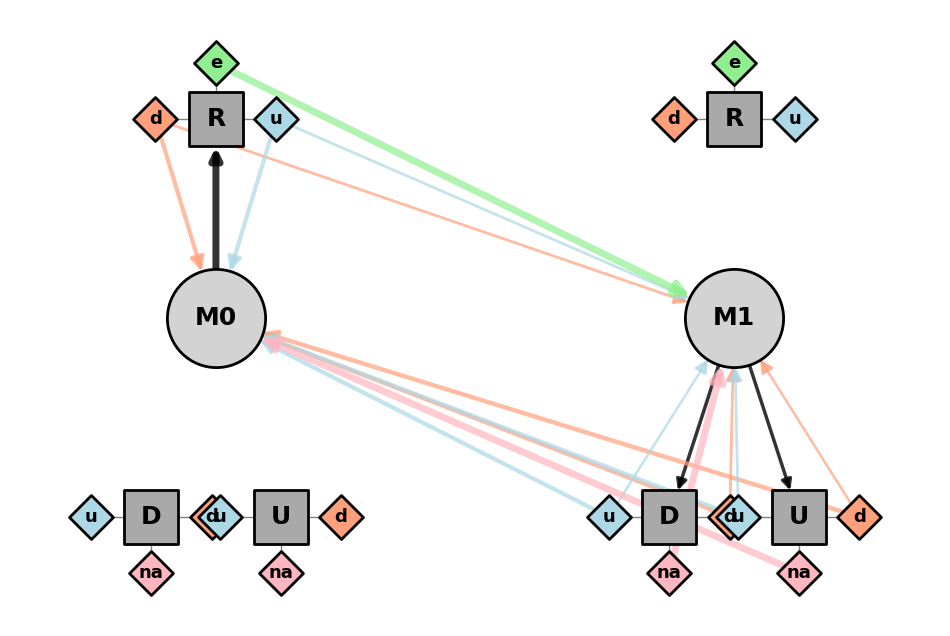

In [16]:
FSC_M2.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue",
                            "lightgreen", "lightpink",
                            ]

ax = FSC_M2.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-3, th_mem_transitions=1e-3,
                     AllowedObsFromAct=AllowedObsFromAct)
plt.show()

In [17]:
FSC_M2.save(path_to_save, custom_postname = f'length_{CORRIDOR_LENGTH}_endact_det_bias')

FSC saved in ../data/TMaze/FSC_discrete_softmax_M2_A3_Y4_trained_loss8.505271_length_7_endact_det_bias.pkl


## M = 3

In [18]:
NEpochs_MAPSO = 2000
M = 3
MemSpace = np.array(["M" + str(num) for num in range(M)])
psi_init = np.ones(M)
psi_init[1:] = -np.inf

FSC_M3 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": None, "zeta": None},
                          psi = psi_init.copy(),
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M3.set_inference_params(use_gradient = False, use_MAPSO = True,
                              trainable_parameters = ["zeta", "theta"],
                              n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                              dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                              num_neighbors_mid_MAPSO = 2,
                              init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1}, # 1
                              init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                              print_params = False)
        
_ = FSC_M3.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 9.602806605978428
Iteration 1/2000, best value: 9.602806605978428
Iteration 2/2000, best value: 9.43658681822589
Iteration 3/2000, best value: 9.43658681822589
Iteration 4/2000, best value: 9.242213695787104
Iteration 5/2000, best value: 9.131616597727106
Iteration 6/2000, best value: 8.851691433515036
Iteration 7/2000, best value: 8.851691433515036
Iteration 8/2000, best value: 8.851691433515036
Iteration 9/2000, best value: 8.851691433515036
Iteration 10/2000, best value: 8.851691433515036
Iteration 11/2000, best value: 8.851691433515036
Iteration 12/2000, best value: 8.851691433515036
Iteration 13/2000, best value: 8.844549259510728
Iteration 14/2000, best value: 8.838803525563865
Iteration 15/2000, best value: 8.83604517962035
Iteration 16/2000, best value: 8.805964996724638
Iteration 17/2000, best value: 8.805964996724638
Iteration 18/2000, best value: 8.805958999906329
Iteration 19/2000, best value: 8.805589927379526
Iteration 20/2000, best value: 8.8054378598

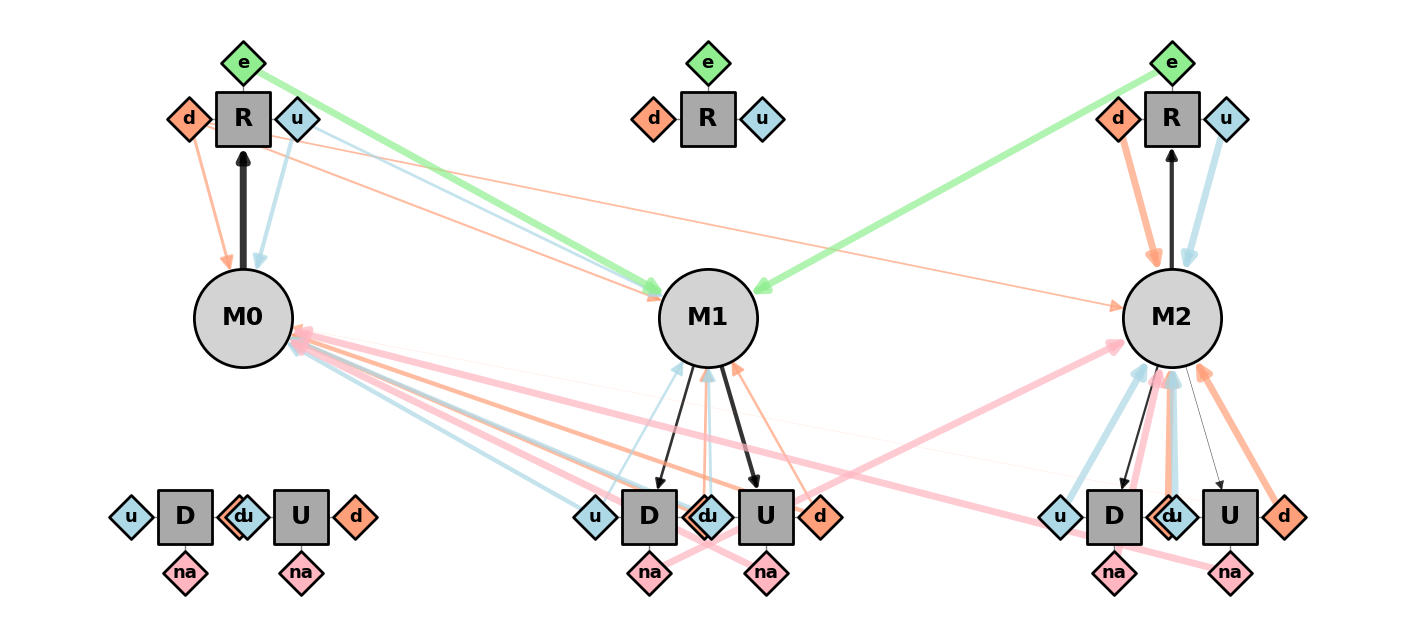

In [19]:
FSC_M3.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue",
                            "lightgreen", "lightpink",
                            ]

ax = FSC_M3.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-3, th_mem_transitions=1e-3,
                     AllowedObsFromAct = AllowedObsFromAct)
plt.show()

In [20]:
FSC_M3.save(path_to_save, custom_postname = f'length_{CORRIDOR_LENGTH}_endact_det_bias')

FSC saved in ../data/TMaze/FSC_discrete_softmax_M3_A3_Y4_trained_loss8.378538_length_7_endact_det_bias.pkl


## M = 4

In [21]:
NEpochs_MAPSO = 2000
M = 4
MemSpace = np.array(["M" + str(num) for num in range(M)])
psi_init = np.ones(M)
psi_init[1:] = -np.inf

FSC_M4 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": None, "zeta": None},
                          psi = psi_init.copy(),
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M4.set_inference_params(use_gradient = False, use_MAPSO = True,
                              trainable_parameters = ["zeta", "theta"],
                              n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                              dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                              num_neighbors_mid_MAPSO = 2,
                              init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1}, # 1
                              init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                              print_params = False)
        
_ = FSC_M4.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 9.546413485235671
Iteration 1/2000, best value: 9.546413485235671
Iteration 2/2000, best value: 9.265984722254696
Iteration 3/2000, best value: 9.265984722254696
Iteration 4/2000, best value: 9.158957060312515
Iteration 5/2000, best value: 9.158957060312515
Iteration 6/2000, best value: 9.024495805854324
Iteration 7/2000, best value: 9.024495805854324
Iteration 8/2000, best value: 8.856689426488614
Iteration 9/2000, best value: 8.856689426488614
Iteration 10/2000, best value: 8.856689426488614
Iteration 11/2000, best value: 8.856689426488614
Iteration 12/2000, best value: 8.80955519964298
Iteration 13/2000, best value: 8.80955519964298
Iteration 14/2000, best value: 8.794470387805715
Iteration 15/2000, best value: 8.773399035458873
Iteration 16/2000, best value: 8.773177415982014
Iteration 17/2000, best value: 8.773177415982014
Iteration 18/2000, best value: 8.727671002980344
Iteration 19/2000, best value: 8.724783209627033
Iteration 20/2000, best value: 8.724016007

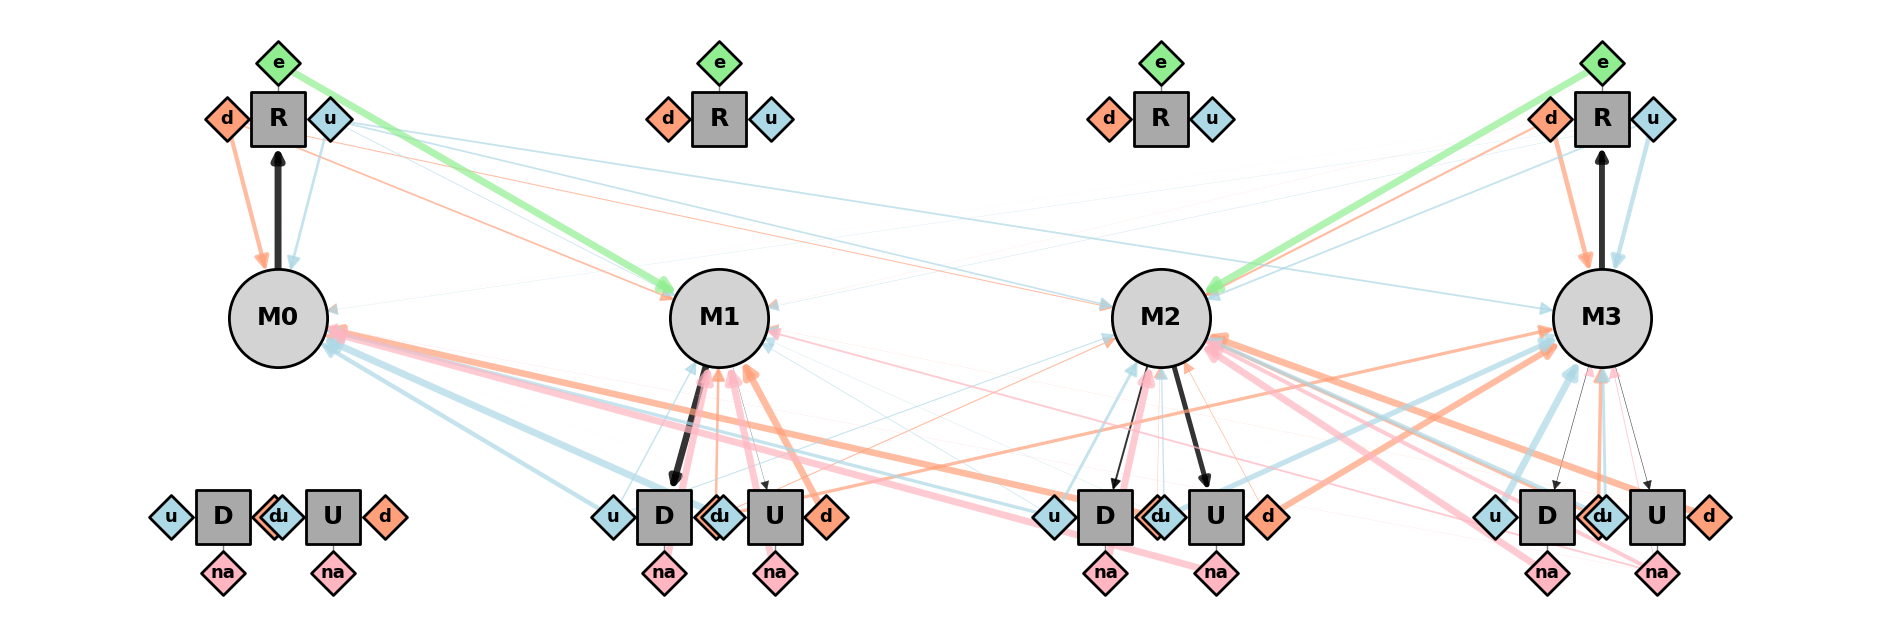

In [22]:
FSC_M4.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue",
                            "lightgreen", "lightpink",
                            ]

ax = FSC_M4.plot_FSC(observation_node_colors=observation_node_colors,
                     th_action_probs=1e-3, th_mem_transitions=1e-3,
                     AllowedObsFromAct = AllowedObsFromAct)
plt.show()

In [23]:
FSC_M4.save(path_to_save, custom_postname = f'length_{CORRIDOR_LENGTH}_endact_det_bias')

FSC saved in ../data/TMaze/FSC_discrete_softmax_M4_A3_Y4_trained_loss8.290626_length_7_endact_det_bias.pkl


## M = 5

In [32]:
M = 5

trainable_mask = {}

trainable_mask_psi = np.zeros(M, dtype=bool)
psi_init = np.ones(M)
psi_init[1:] = -np.inf

trainable_mask_zeta = np.ones((A, M), dtype=bool)
zeta_init = np.zeros((A, M))

trainable_mask_theta = np.ones((Y, A, M, M), dtype=bool)
theta_init = np.zeros((Y, A, M, M))

theta_init[idx_obs_na] = -np.inf
trainable_mask_theta[idx_obs_na] = False

for idx_m in range(M):
    theta_init[idx_obs_na, :, idx_m, idx_m] = 1

trainable_mask["theta"] = trainable_mask_theta
trainable_mask["psi"] = trainable_mask_psi
trainable_mask["zeta"] = trainable_mask_zeta

In [ ]:
NEpochs_MAPSO = 2000
M = 5
MemSpace = np.array(["M" + str(num) for num in range(M)])

FSC_M5 = controller.FSC(M = M, A = A, Y = Y,
                          mode = "inference",
                          policy_model = "softmax",
                          policy_params = {"theta": theta_init.copy(), "zeta": zeta_init.copy()},
                          psi = psi_init.copy(),
                          ActSpace = ActSpace, MemSpace = MemSpace,
                          ObsSpace = ObsSpace)

FSC_M5.set_inference_params(use_gradient = False, use_MAPSO = True,
                            trainable_parameters = "elementwise_mask",
                            trainable_mask = trainable_mask,
                            n_particles_MAPSO = 50, NEpochs_MAPSO = NEpochs_MAPSO,
                            dynamic_topology_MAPSO = True, num_neighbors_init_MAPSO = 50, num_neighbors_final_MAPSO = 50,
                            num_neighbors_mid_MAPSO = 2,
                            init_particles_MAPSO = {"distribution": "normal", "mean": 0, "std": 1},
                            init_velocities_MAPSO = {"distribution": "uniform", "vmin": -0.01, "vmax": +0.01},
                            print_params = False)
        
_ = FSC_M5.fit(trajectories_data, verbose_MAPSO=False,
                    verbose_epochs_MAPSO=True)

Initial best value: 9.602229611041643
Iteration 1/2000, best value: 9.602229611041643
Iteration 2/2000, best value: 9.54512292363136
Iteration 3/2000, best value: 9.474327367720363
Iteration 4/2000, best value: 9.195901845739954
Iteration 5/2000, best value: 9.193921864615634
Iteration 6/2000, best value: 9.193921864615634
Iteration 7/2000, best value: 9.193921864615634
Iteration 8/2000, best value: 9.184468798270123
Iteration 9/2000, best value: 9.181173459524592
Iteration 10/2000, best value: 9.181173459524592
Iteration 11/2000, best value: 9.181173459524592
Iteration 12/2000, best value: 9.17362228013234
Iteration 13/2000, best value: 9.17362228013234
Iteration 14/2000, best value: 9.142589244925214
Iteration 15/2000, best value: 9.142529907745779
Iteration 16/2000, best value: 9.142444301066934
Iteration 17/2000, best value: 9.142248212047994
Iteration 18/2000, best value: 9.142248180672583
Iteration 19/2000, best value: 9.085224016474907
Iteration 20/2000, best value: 9.0852240164

[1. 0. 0. 0. 0.]


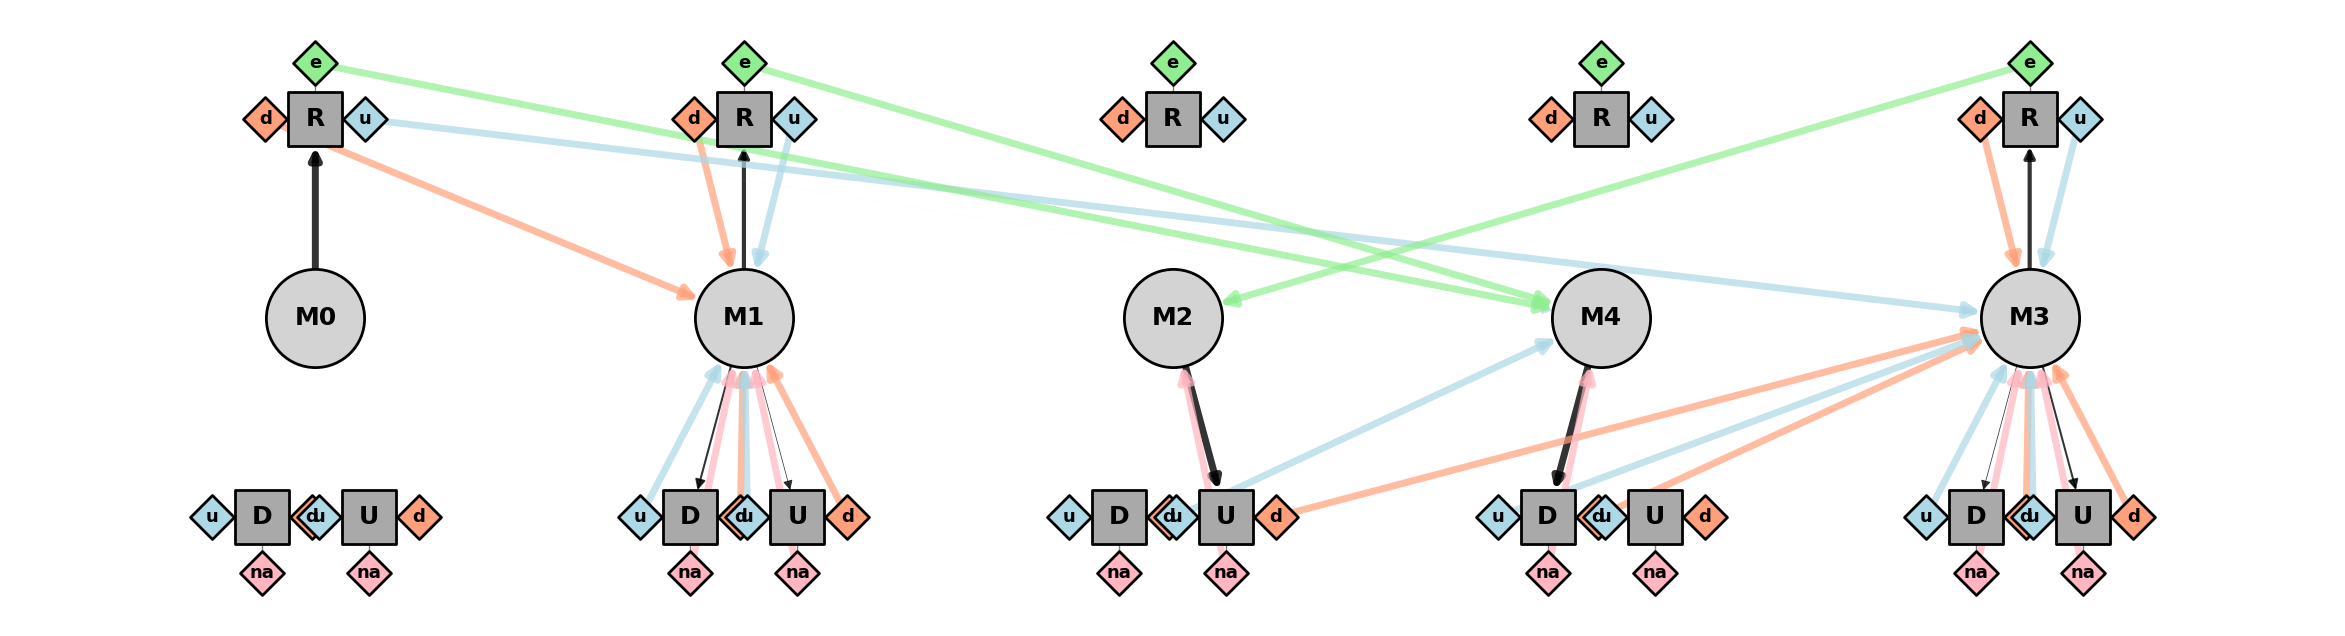

In [37]:
FSC_M5.set_mode("generation")
observation_node_colors = ["lightsalmon", "lightblue",
                            "lightgreen", "lightpink"
                            ]

print(FSC_M5.rho)

ax = FSC_M5.plot_FSC(observation_node_colors=observation_node_colors,
                     memory_ordering = [0, 1, 2, 4, 3],
                     th_action_probs=1e-3, th_mem_transitions=1e-3,
                     AllowedObsFromAct = AllowedObsFromAct, fade_no_incoming = False)
plt.show()

In [ ]:
FSC_M5.save(path_to_save, custom_postname = f'length_{CORRIDOR_LENGTH}_endact_det_bias')